# INTRODUCCIÓN A LOS DATAFRAMES

In [1]:
import pandas as pd

In [2]:
iris_df = pd.read_csv(r'https://raw.githubusercontent.com/toneloy/data/master/iris.csv')  # leer el archivo iris.csv en la web.

In [3]:
iris_df.head(8)  #este comando permite visualizar los primeros 5 registros , si escribimos iris_df.head(8) me entrega los primeros 10 registros

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa


In [4]:
iris_df[['species', 'petal_length']] # se obtiene dos campos del dataset

,species,petal_length
0,setosa,1.4
1,setosa,1.4
2,setosa,1.3
3,setosa,1.5
4,setosa,1.4
...,...,...
145,virginica,5.2
146,virginica,5.0
147,virginica,5.2
148,virginica,5.4


In [5]:
iris_df['petal_length'].mean() # sirve para obtener la media

np.float64(3.7580000000000005)

In [6]:
iris_df.describe() # sirve para obtener todos los estadísticos descriptivos del dataset

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# ANALISIS EXPLORATORIO DE DATOS

Se debe importar todas las librerias para realizar la exploración

In [7]:
import pandas as pd  # libreria para obtener datos y usar ciencia de datos
import matplotlib.pyplot as plt # libreria para realizar gráficas
import seaborn as sns #libreria para hacer gráficas, mas elaboradas que la enterior
import numpy as np # libreria que tiene metodos numericos para python
from scipy.stats import norm 
from sklearn.preprocessing import StandardScaler
from scipy import stats 
%matplotlib inline 
plt.rcParams['font.size'] = 15

In [8]:
iris_df['species'].unique()

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str

<Axes: xlabel='species'>

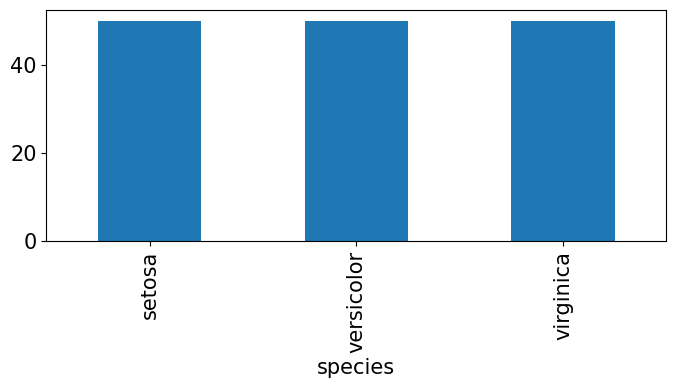

In [9]:
iris_df.value_counts(iris_df['species']).plot.bar( figsize = (8,3))

## BoxPlots para longitud Y ancho de sépalo y longitud y anchos de pétalo

In [10]:
var = 'species' #se define esta variable species para almacenar el nombre de la variable categorica 

### Se crea conjuntos de datos  de longitudes  por cada especie , concatenando 

In [12]:
datosLongitudSepalo = pd.concat([iris_df['sepal_length'],iris_df[var]], axis = 1) 
datosAnchoSepalo = pd.concat([iris_df['sepal_width'],iris_df[var]], axis = 1)
datosLongitudPetalo = pd.concat([iris_df['petal_length'],iris_df[var]], axis = 1)
datosAnchoPetalo = pd.concat([iris_df['petal_width'],iris_df[var]], axis = 1)


In [13]:
datosLongitudSepalo.head(5)


,sepal_length,species
0,5.1,setosa
1,4.9,setosa
2,4.7,setosa
3,4.6,setosa
4,5.0,setosa


In [14]:
datosAnchoSepalo.head(5)

,sepal_width,species
0,3.5,setosa
1,3.0,setosa
2,3.2,setosa
3,3.1,setosa
4,3.6,setosa


In [15]:
datosLongitudPetalo.head(5)


,petal_length,species
0,1.4,setosa
1,1.4,setosa
2,1.3,setosa
3,1.5,setosa
4,1.4,setosa


In [16]:
datosAnchoPetalo.head(5)

,petal_width,species
0,0.2,setosa
1,0.2,setosa
2,0.2,setosa
3,0.2,setosa
4,0.2,setosa


C:\Users\Jose.Hurtado\AppData\Local\Temp\ipykernel_16668\2719270015.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.boxplot(x=var, y="sepal_length", data =datosLongitudSepalo, palette =['blue', 'orange', 'green'])   # se dibuja el boxplot
C:\Users\Jose.Hurtado\AppData\Local\Temp\ipykernel_16668\2719270015.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  fig = sns.boxplot(x=var, y="sepal_width", data =datosAnchoSepalo, palette =['blue', 'orange', 'green'])   # se dibuja el boxplot
C:\Users\Jose.Hurtado\AppData\Local\Temp\ipykernel_16668\2719270015.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and se

(np.float64(-0.5), np.float64(2.5), np.float64(0.0), np.float64(3.0))

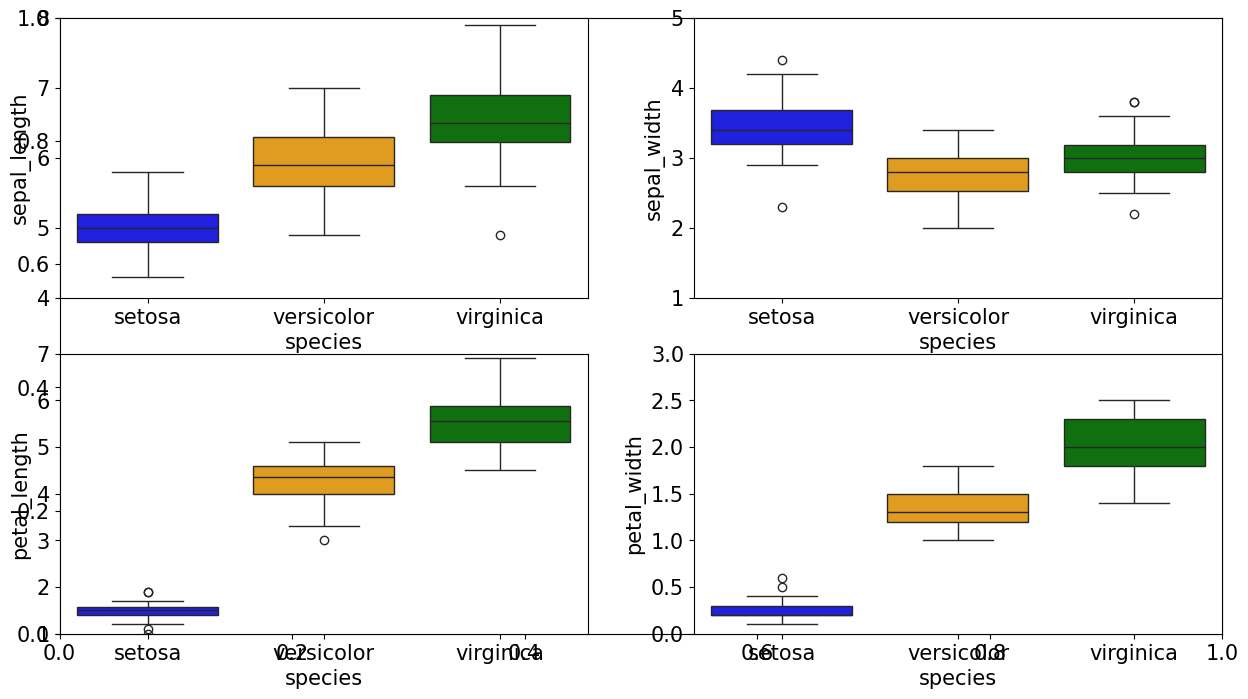

In [17]:
var = 'species' 

f, ax =   plt.subplots(figsize=(15,8)) #area en donde voy a graficar

plt.subplot (2,2,1) # define posicion izquierda para primer grafico
fig = sns.boxplot(x=var, y="sepal_length", data =datosLongitudSepalo, palette =['blue', 'orange', 'green'])   # se dibuja el boxplot
fig.axis (ymin=4, ymax=8) 

plt.subplot (2,2,2)  #define posicion para segundo grafico
fig = sns.boxplot(x=var, y="sepal_width", data =datosAnchoSepalo, palette =['blue', 'orange', 'green'])   # se dibuja el boxplot
fig.axis (ymin=1, ymax=5) 

plt.subplot (2,2,3) # define posicion izquierda para primer grafico
fig = sns.boxplot(x=var, y="petal_length", data =datosLongitudPetalo, palette =['blue', 'orange', 'green'])   # se dibuja el boxplot
fig.axis (ymin=1, ymax=7) 

plt.subplot (2,2,4)  #define posicion para segundo grafico
fig = sns.boxplot(x=var, y="petal_width", data =datosAnchoPetalo, palette =['blue', 'orange', 'green'])   # se dibuja el boxplot
fig.axis (ymin=0, ymax=3) 



# SCATTERPLOT o Diagrama de Dispersión

<Axes: xlabel='petal_length', ylabel='petal_width'>

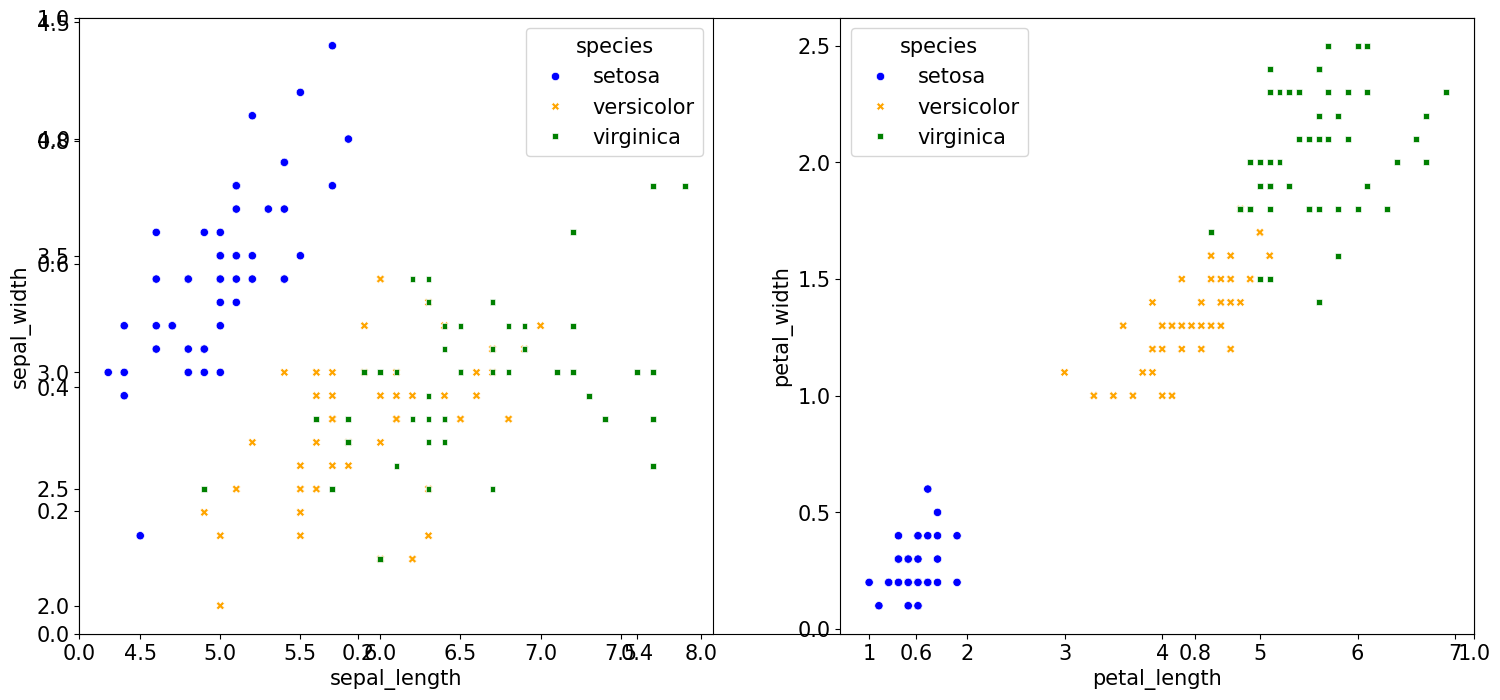

In [18]:
f, ax =   plt.subplots(figsize=(18,8)) #area en donde voy a graficar
plt.subplot (1,2,1)
sns.scatterplot (x = iris_df.sepal_length, y = iris_df.sepal_width, hue = iris_df.species, style = iris_df.species, palette =['blue', 'orange', 'green'])
plt.subplot (1,2,2)
sns.scatterplot (x = iris_df.petal_length, y = iris_df.petal_width, hue = iris_df.species, style = iris_df.species, palette =['blue', 'orange', 'green'])



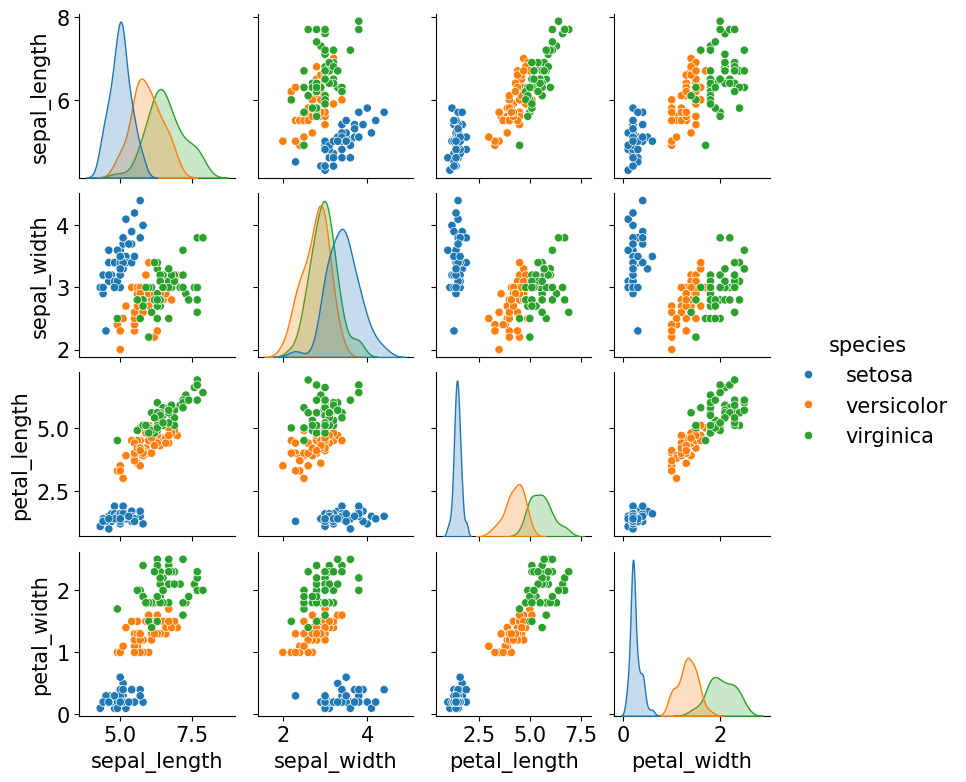

In [19]:
sns.pairplot(iris_df,  hue='species', height=2)

# Algoritmo de agrupacion para diferentes valores de K

### se debe hallar el valor óptimo de K
### se aplica el método del codo para hallar K
### Se calcula el algoritmo de agrupacion para diferentes valores de K

In [20]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans

In [21]:
iris_df.loc[30]

sepal_length       4.8
sepal_width        3.1
petal_length       1.6
petal_width        0.2
species         setosa
Name: 30, dtype: object

In [22]:
iris_df.loc[51]

sepal_length           6.4
sepal_width            3.2
petal_length           4.5
petal_width            1.5
species         versicolor
Name: 51, dtype: object

In [23]:
iris_df.loc[120]

sepal_length          6.9
sepal_width           3.2
petal_length          5.7
petal_width           2.3
species         virginica
Name: 120, dtype: object

In [24]:
iris_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [25]:
#Se elige aleatoriamente con cualquier mecanismo el registro 30, el registro 51 y el registro 120, usando la función loc del dataframe:
indiceMuestra =[30,51,120]
muestras = pd.DataFrame (iris_df.loc[indiceMuestra], columns = iris_df.keys()).reset_index(drop =True)

In [26]:
muestras

,sepal_length,sepal_width,petal_length,petal_width,species
0,4.8,3.1,1.6,0.2,setosa
1,6.4,3.2,4.5,1.5,versicolor
2,6.9,3.2,5.7,2.3,virginica


In [27]:
#Una vez escogidas las muestras, estas se eliminan de la data original iris_df, de los datos de muestra, para que estos no se integren con el resto de la información.
iris_df= iris_df.drop(indiceMuestra, axis = 0)

In [28]:
iris_df.info()

<class 'pandas.DataFrame'>
Index: 147 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  147 non-null    float64
 1   sepal_width   147 non-null    float64
 2   petal_length  147 non-null    float64
 3   petal_width   147 non-null    float64
 4   species       147 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.9 KB


In [29]:
iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.839456,3.055102,3.754422,1.196599
std,0.826161,0.439985,1.766012,0.759724
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.550000,0.300000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.350000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


En una variable X se guardan las columnas con valores del dataset original, con los cuales se va a entrenar el algoritmo; para esto se usa la función iloc sobre el dataset original iris_df. Estos datos corresponden a las variables de longitudes y anchos de los sépalos y los pétalos únicamente.

El conjunto de datos no cuenta con una columna de variable dependiente o Y en aprendizaje no supervisado, todos son variables dependientes, en este caso es X.

In [30]:
X = iris_df.iloc[:, [0, 1, 2,3]].values
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.2],
       [5. , 3

In [31]:
iris_df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,147.000000,147.000000,147.000000,147.000000
mean,5.839456,3.055102,3.754422,1.196599
std,0.826161,0.439985,1.766012,0.759724
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.550000,0.300000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.350000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


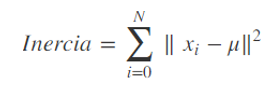

In [32]:
inercia =[] # suma de cuadrados
for i in range (1,20): 
        algoritmo = KMeans (n_clusters  = i, max_iter =300).fit(X)
        inercia.append(algoritmo.inertia_)

<function matplotlib.pyplot.show(close=None, block=None)>

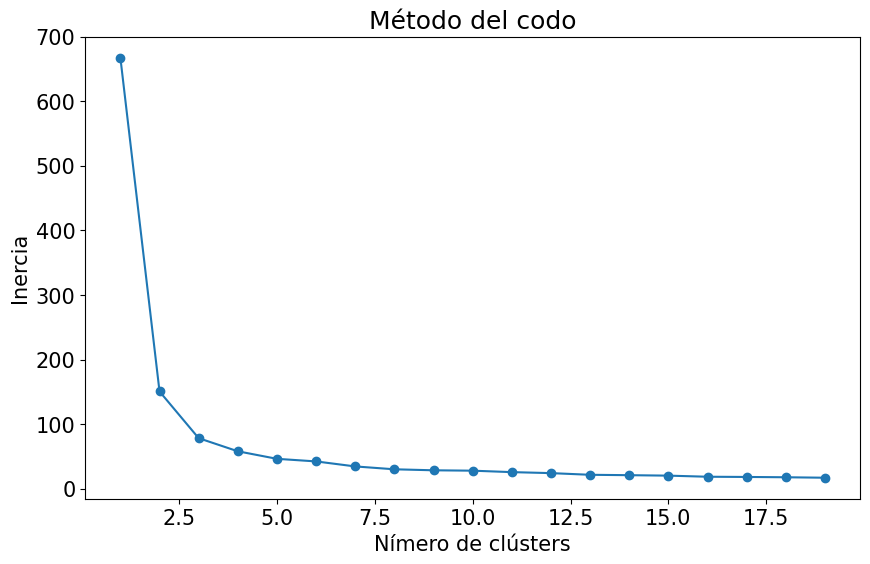

In [33]:
plt.figure(figsize =[10,6])
plt.title('Método del codo')
plt.xlabel('Nímero de clústers')
plt.ylabel('Inercia')
plt.plot ( list(range(1,20)), inercia, marker='o')
plt.show


In [34]:
#n_clusters = 3 porque según el gráfico anterior, el codo está entre 2.5 y 5, se tomó k=3 entonces.
algoritmo = KMeans( n_clusters=3, init ='k-means++', max_iter=300, n_init =10)

In [35]:
algoritmo.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [36]:
centroides, etiquetas = algoritmo.cluster_centers_, algoritmo.labels_

In [37]:
centroides

array([[5.875     , 2.73333333, 4.38666667, 1.43333333],
       [5.01020408, 3.43469388, 1.45918367, 0.24693878],
       [6.85263158, 3.07368421, 5.71578947, 2.04736842]])

In [38]:
etiquetas

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 2, 0, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2, 2, 0, 2,
       2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [39]:
Xmuestras = muestras.iloc[:, [0, 1, 2, 3]].values
YMuestraPrediccion = algoritmo.predict (Xmuestras )

In [40]:
print (YMuestraPrediccion)

[1 0 2]


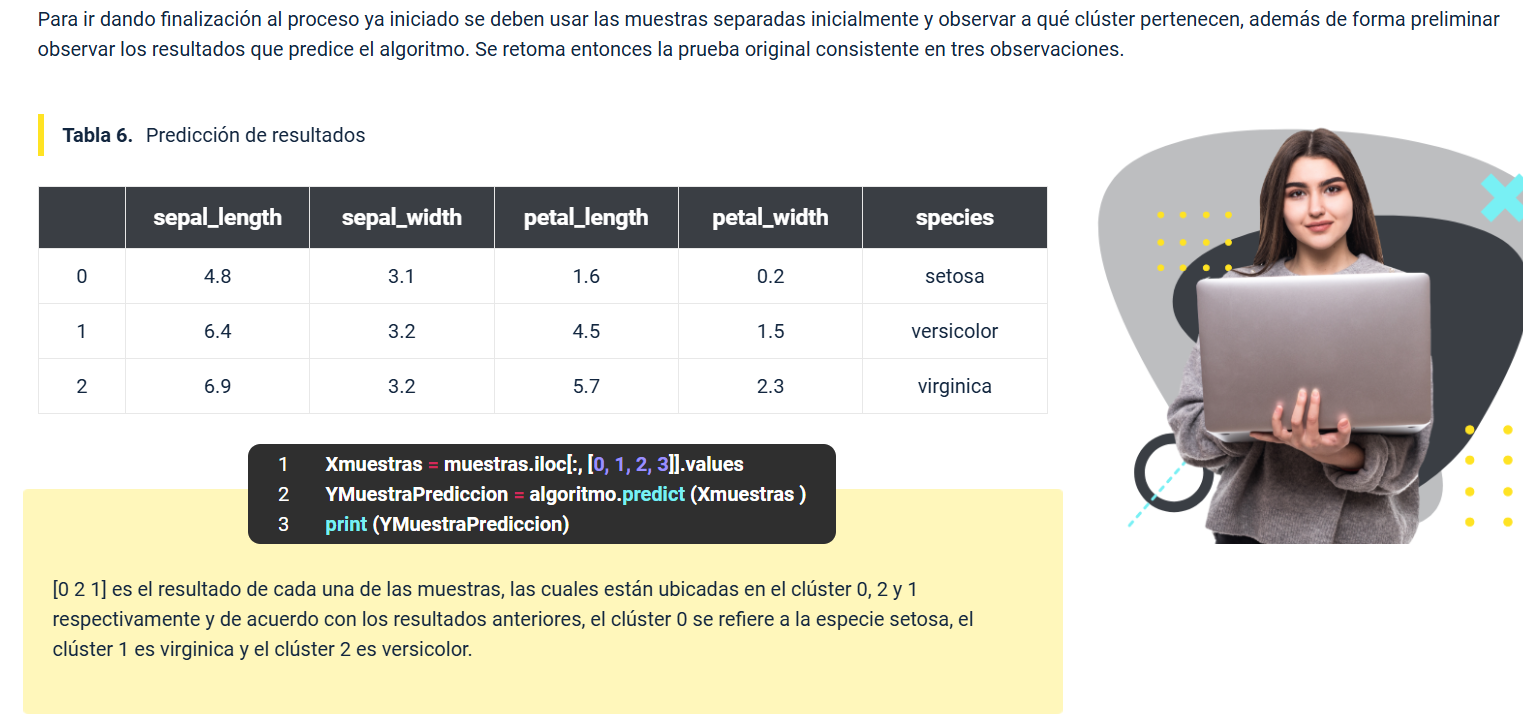

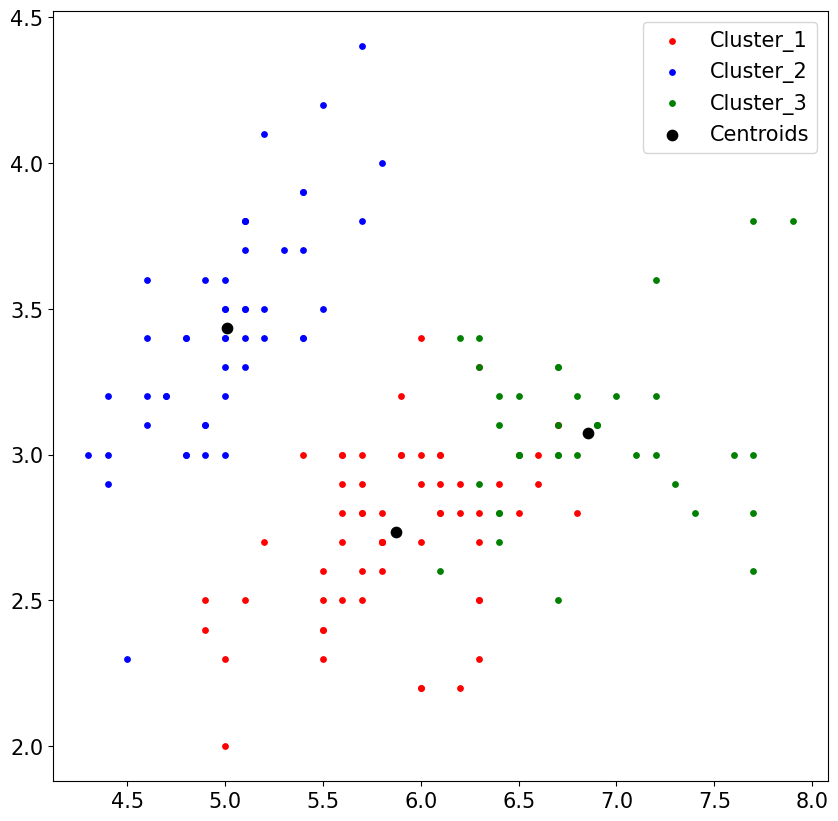

In [41]:
#Aplicando k-means al dataset / creacion del clasificador con k-means
plt.figure(figsize =[10,10])
plt.scatter(X[etiquetas == 0,0], X[etiquetas==0,1], s = 15, c= 'red', label = 'Cluster_1')
plt.scatter(X[etiquetas== 1,0], X[etiquetas==1,1], s = 15, c= 'blue', label = 'Cluster_2')
plt.scatter(X[etiquetas == 2,0], X[etiquetas==2,1], s = 15, c= 'green', label = 'Cluster_3')
plt.scatter(centroides[:,0], centroides[:,1], s = 55, c = 'black', label = 'Centroids')
plt.legend()
plt.show()

En este caso se han graficado los clústeres obtenidos, teniendo en cuenta la longitud y ancho del sépalo que son las columnas 0 y 1 del dataset, se observa que el clúster 0 de color rojo podría ser los datos de la especie setosa, el clúster 1 de color azul equivale a la especie virgínica y el clúster 2 de color verde corresponde al versicolor.

In [331]:
datos_flor =np.array([1,3,5,2])
datos_flor_fm =datos_flor.reshape(1, -1) #con este comando se le dice a python que cambie el array a una matriz de una sola fila
datos_flor_fm
algoritmo.predict(datos_flor_fm)

array([2], dtype=int32)